In [1]:
import numpy as np
import matplotlib.pyplot as plt
import zarr
from zarr.core.group import GroupMetadata
import dask
import dask.array as da
import gc
from multiview_stitcher import vis_utils
from multiview_stitcher import fusion, msi_utils, ngff_utils, registration
from multiview_stitcher import spatial_image_utils as si_utils
from pathlib import Path
from tqdm import tqdm
from merfish3danalysis.qi2labDataStore import qi2labDataStore

In [2]:
def _load_ome_zarr_image_array(path: Path) -> np.ndarray:
    """Load the image array from an OME-Zarr group."""

    root = zarr.open_group(str(path), mode="r")
    array_keys = list(root.array_keys())
    if not array_keys:
        raise RuntimeError(f"No arrays were found inside OME-Zarr group {path!s}.")

    array_name = "0" if "0" in array_keys else array_keys[0]
    return root[array_name]

_original_group_from_dict = GroupMetadata.from_dict.__func__

def _ignore_extra_attributes(cls, data):
    data = dict(data)
    data.pop("extra_attributes", None)
    return _original_group_from_dict(cls, data)

GroupMetadata.from_dict = classmethod(_ignore_extra_attributes)

In [3]:
root_path = "/data/smfish/20260311_bartelle_smFISH_cryo_48hr_male/"

In [4]:
# initialize datastore
print("\nInitializing datastore...")
datastore_path = root_path / Path(r"qi2labdatastore")
datastore = qi2labDataStore(datastore_path)
print("Using datastore at "+ str(datastore_path))
gene_ids = list(datastore.codebook["gene_id"])
channel_ids = ["fiducial", *gene_ids]
print(channel_ids)


Initializing datastore...
Using datastore at /data/smfish/20260311_bartelle_smFISH_cryo_48hr_male/qi2labdatastore
['fiducial', 'Angpt1', 'Crmp1', 'Dcx', 'Hdac11', 'Itgam', 'Notch2', 'Ptch1', 'Serpine1', 'Shh', 'Slc1a3', 'Tcf12', 'Tek', 'Tgfb1', 'Tgfbi', 'Aif1', 'Nnat']


In [5]:
# define output path
fused_path = root_path / Path("fused")
fused_path.mkdir(exist_ok=True)

In [6]:
# define shape of registered image using round 0 and a temporary variable im_data
im_data = datastore.load_local_registered_image(
    tile=0, round=0, return_future=False
)

im_shape = im_data.shape
print(im_shape)
del im_data

(60, 2048, 2048)


In [7]:
# convert local tiles from first round to multiscale spatial images
# msims contain image data and metadata like coodinate system, voxel spacing, and transformation information
print("\nLazy loading fiducial channel...")
msims = []
for _, tile_id in enumerate(tqdm(datastore.tile_ids, desc="tile")):
    # load voxel size
    voxel_zyx_um = datastore.voxel_size_zyx_um

    # format voxel size for multiview-stitcher
    scale = {"z": voxel_zyx_um[0], "y": voxel_zyx_um[1], "x": voxel_zyx_um[2]}

    # load stage positions and camera <-> stage mapping from first round of imaging
    # all tiles are already mapped to round 0, so we use this as the coordinate system
    tile_position_zyx_um, affine_zyx_px = (
        datastore.load_local_stage_position_zyx_um(tile_id, datastore.round_ids[0])
    )

    # format tile positions for multiview-stitcher
    tile_grid_positions = {
        "z": np.round(tile_position_zyx_um[0], 2),
        "y": np.round(tile_position_zyx_um[1], 2),
        "x": np.round(tile_position_zyx_um[2], 2),
    }

    # create empty array to hold all channels for this tile
    im_data = da.zeros((1, im_shape[0], im_shape[1], im_shape[2]), dtype=np.uint16)

    # find the Zarr file for this tile's fiducial channel, load the deconvolved data from it, and put it into the first channel of your multi-channel image array.

    # construct the file path
    input_path = (
        datastore_path
        / Path("fiducial")
        / Path(tile_id)
        / Path("round001")
        / Path("registered_decon_data.ome.zarr")
    )

    # load image data from zarr file
    im_data[0, :] = da.from_array(
        _load_ome_zarr_image_array(input_path),
        chunks=im_shape,
    ).astype(np.uint16)  

    print(f"data loaded for tile {tile_id}")          

    # create spatial image for all channels in current tile
    sim = si_utils.get_sim_from_array(
        im_data,
        dims=("c", "z", "y", "x"),
        scale=scale,
        translation=tile_grid_positions,
        affine=affine_zyx_px,
        transform_key="stage_metadata",
    )

    # convert to multiscale spatial image object and append to list for registration
    msim = msi_utils.get_msim_from_sim(sim, scale_factors=[])
    msims.append(msim)
    del im_data
    gc.collect()


Lazy loading fiducial channel...


tile:   0%|          | 0/154 [00:00<?, ?it/s]

data loaded for tile tile0000


tile:   1%|▏         | 2/154 [00:00<00:34,  4.37it/s]

data loaded for tile tile0001
data loaded for tile tile0002


...

tile:  99%|█████████▊| 152/154 [00:25<00:00,  3.40it/s]

data loaded for tile tile0152


tile:  99%|█████████▉| 153/154 [00:25<00:00,  3.57it/s]

data loaded for tile tile0153


tile: 100%|██████████| 154/154 [00:26<00:00,  5.88it/s]


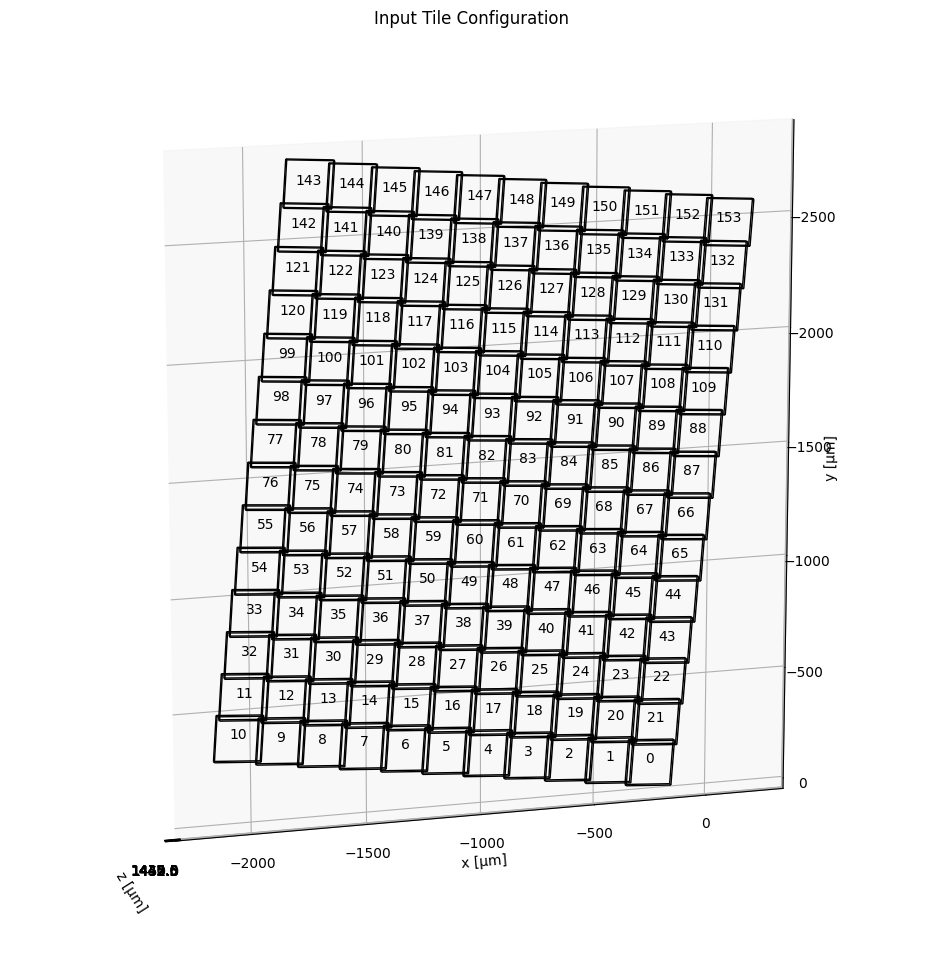

fusion plot finished


In [ ]:
# plot the tile configuration
fig, ax = vis_utils.plot_positions(
    msims,
    transform_key='stage_metadata',
    use_positional_colors=False,
    show_plot=False,
    plot_title="Input Tile Configuration"
)
fig.set_size_inches(14, 10)
fig.tight_layout(pad=2.0)
plt.show()

print("fusion plot finished")